# Part 3: NLP and Sequence Modeling Mini Project

This notebook covers the development of an NLP pipeline to classify customer support text queries using both traditional machine learning and sequence-based deep learning.

## Task 1: Dataset Understanding
Load and analyze the text dataset.

Total records: 1500

First 5 records:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0



Class (Sentiment) Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average text length: 72.76 characters


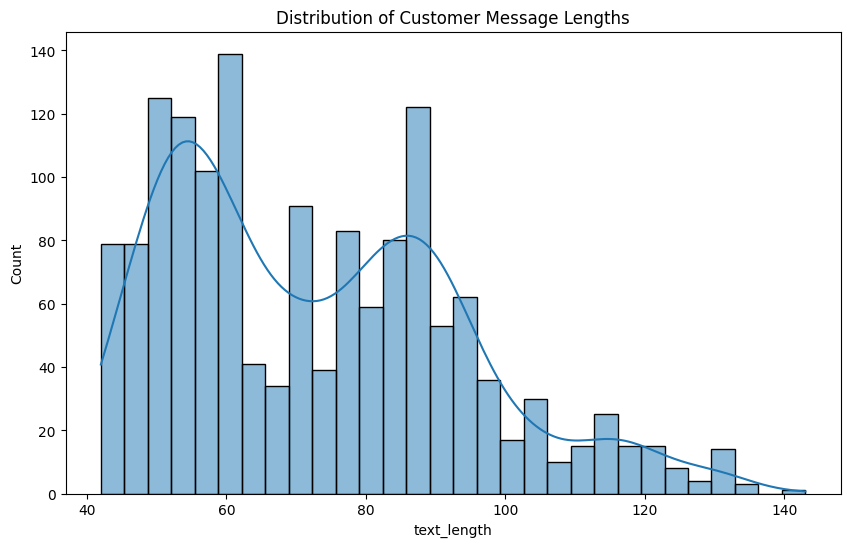

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "../ai_project_synthetic_datasets-20260508T104820Z-3-001/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv"
df = pd.read_csv(dataset_path)

print(f"Total records: {len(df)}")
print("\nFirst 5 records:")
display(df.head())

print("\nClass (Sentiment) Distribution:")
print(df['sentiment_label'].value_counts())

# Text length analysis
df['text_length'] = df['customer_message'].apply(len)
print(f"\nAverage text length: {df['text_length'].mean():.2f} characters")

plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Distribution of Customer Message Lengths')
plt.show()

## Task 2 & 3: Text Preprocessing and Vectorization
Clean the text and convert it into numerical format.

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# Split data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df['cleaned_text'], df['sentiment_label'], test_size=0.2, random_state=42)

# Vectorization for Baseline (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"TF-IDF feature count: {len(tfidf.get_feature_names_out())}")

TF-IDF feature count: 146


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amantya/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Task 4: Baseline Model
Build a simple baseline model (Logistic Regression).

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

y_pred = baseline_model.predict(X_test_tfidf)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Task 5: Sequence Model (LSTM)
Build a deep learning sequence model.

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

MAX_WORDS = 10000
MAX_LEN = 50

# Tokenization
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LEN)

# Label Encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# Build LSTM Model
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

I0000 00:00:1778245140.043878 1547080 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778245140.044484 1547080 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778245140.078260 1547080 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778245141.023266 1547080 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778245141.023623 1547080 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


/home/amantya/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1778245141.279826 1547080 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Conceptual Architecture Explanation

1.  **Input Sequence**: Numerical indices representing words in a sentence.
2.  **Embedding Layer**: Converts sparse word indices into dense continuous vectors (embeddings), capturing semantic meaning.
3.  **LSTM Layer**: A recurrent layer that processes the sequence word by word, maintaining a "memory" of previous inputs via its cell state.
4.  **Dense Layers**: Standard neural network layers that interpret the patterns extracted by the LSTM.
5.  **Output Layer**: Uses Softmax to output probabilities for each customer support category.
6.  **Loss Function**: Sparse Categorical Crossentropy (suitable for multi-class classification with integer labels).
7.  **Evaluation Metric**: Accuracy.

In [5]:
# Train LSTM
history = lstm_model.fit(X_train_seq, y_train_enc, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate
loss, acc = lstm_model.evaluate(X_test_seq, y_test_enc, verbose=0)
print(f"LSTM Test Accuracy: {acc:.4f}")

# Save Evaluation results
eval_results = pd.DataFrame([{'Model': 'Baseline (Logistic)', 'Accuracy': accuracy_score(y_test, y_pred)}, 
                             {'Model': 'Sequence (LSTM)', 'Accuracy': acc}])
eval_results.to_csv('results/model_evaluation.csv', index=False)

# Sample Predictions
sample_texts = ["my order is delayed", "how to reset my password", "i want a refund"]
sample_seq = pad_sequences(tokenizer.texts_to_sequences(sample_texts), maxlen=MAX_LEN)
preds = lstm_model.predict(sample_seq)

with open('results/sample_predictions.txt', 'w') as f:
    for text, p in zip(sample_texts, preds):
        label = le.inverse_transform([np.argmax(p)])[0]
        f.write(f"Text: {text} -> Predicted: {label}\n")

Epoch 1/10


 1/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.3125 - loss: 1.0998

 5/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3359 - loss: 1.0976

 8/30 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3327 - loss: 1.0962

10/30 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3310 - loss: 1.0952

...

28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 5.5483e-04

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 4.8022e-04 - val_accuracy: 1.0000 - val_loss: 1.5167e-04


LSTM Test Accuracy: 1.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
